# 📊 Buy The Dip Strategy Backtesting

Notebook สำหรับทดสอบ **Buy The Dip Strategy** - กลยุทธ์ซื้อในจังหวะที่ราคาปรับตัวลงในเทรนด์ขาขึ้น

## 🎯 Strategy Logic
- **Entry Signal:** Price > EMA(200) และ RSI < 35
- **Exit Conditions:** 
  - Holding period (default: 5 วัน)
  - Stop Loss: -5%
  - Take Profit: +10%

## 📋 Sections
1. Import & Setup
2. Basic Backtest
3. Custom Parameters Testing
4. Portfolio Backtest
5. Parameter Optimization
6. Results Visualization

## 1️⃣ Import Required Libraries

In [24]:
import sys
import os
import asyncio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Add project root to path
sys.path.insert(0, os.path.abspath('..'))

# Import project modules
from app.data_sources.yfinance_provider import YFinanceProvider
from app.strategies.buy_the_dip_strategy import BuyTheDipStrategy
from app.strategies.base_strategy import StrategyConfig
from app.services.backtest_service import BacktestService
from app.services.portfolio_backtest_service import PortfolioBacktestService
from app.services.optimization_service import ParameterOptimizationService, ParameterRange
from app.models.backtest import TransactionCosts, PositionSizing

# Plotting settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✅ All libraries imported successfully!")
print(f"📅 Current date: {datetime.now().strftime('%Y-%m-%d')}")

✅ All libraries imported successfully!
📅 Current date: 2026-01-03


## 2️⃣ Setup Services & Configuration

In [34]:
# Initialize Data Provider
data_provider = YFinanceProvider()

# Initialize Services
backtest_service = BacktestService(data_provider)
portfolio_service = PortfolioBacktestService(data_provider)
optimization_service = ParameterOptimizationService(backtest_service)

# Test Symbols
TEST_SYMBOL = "GOOGL"
PORTFOLIO_SYMBOLS = ["AAPL", "MSFT", "GOOGL", "NVDA", "TSLA"]

print("✅ Services initialized!")
print(f"🎯 Test Symbol: {TEST_SYMBOL}")
print(f"📊 Portfolio: {', '.join(PORTFOLIO_SYMBOLS)}")

✅ Services initialized!
🎯 Test Symbol: GOOGL
📊 Portfolio: AAPL, MSFT, GOOGL, NVDA, TSLA


## 3️⃣ Basic Backtest - Default Configuration

ทดสอบด้วย parameters มาตรฐาน:
- EMA: 200
- RSI Threshold: 35
- Holding Days: 5
- Stop Loss: 5%
- Take Profit: 10%

In [35]:
# Run backtest with UPDATED parameters
result = await backtest_service.run_backtest(
    symbol=TEST_SYMBOL,
    strategy_name="buy_the_dip",
    days=365,
    config=StrategyConfig(
        name="buy_the_dip",
        holding_days=20,  
        stop_loss_pct=5.0,
        # 3. ปิด Fixed TP เพื่อให้ Trailing Stop ทำงาน
        take_profit_pct=0.0,
        parameters={
            "ema_length": 50,
            "rsi_threshold": 35 
        }
    )
)

# Display results
print(f"{'='*60}")
print(f"📊 BACKTEST RESULTS - {result.symbol}")
print(f"{'='*60}")
print(f"Strategy: {result.strategy_name}")
print(f"Period: {result.period_days} days ({result.start_date.date()} to {result.end_date.date()})")
print(f"\n{'─'*60}")
print(f"📈 PERFORMANCE METRICS")
print(f"{'─'*60}")
print(f"Total Return:        {result.total_return:>8.2f}%")
print(f"Buy & Hold Return:   {result.buy_and_hold_return:>8.2f}%")
print(f"Alpha (Excess):      {result.alpha:>8.2f}%")
print(f"\n{'─'*60}")
print(f"📊 TRADE STATISTICS")
print(f"{'─'*60}")
print(f"Total Trades:        {result.total_trades:>8}")
print(f"Win Rate:            {result.win_rate:>8.2f}%")
print(f"Average Return:      {result.avg_return:>8.2f}%")
print(f"Best Trade:          {result.best_trade:>8.2f}%")
print(f"Worst Trade:         {result.worst_trade:>8.2f}%")
print(f"\n{'─'*60}")
print(f"💰 CAPITAL & COSTS")
print(f"{'─'*60}")
print(f"Initial Capital:     ${result.initial_capital:>10,.2f}")
print(f"Final Capital:       ${result.final_capital:>10,.2f}")
print(f"Net Profit:          ${result.net_profit:>10,.2f}")
print(f"Transaction Costs:   ${result.total_transaction_costs:>10,.2f}")
print(f"Avg Cost/Trade:      ${result.avg_cost_per_trade:>10,.2f}")
print(f"\n{'─'*60}")
print(f"📉 RISK METRICS")
print(f"{'─'*60}")
print(f"Sharpe Ratio:        {result.sharpe_ratio:>8.2f}")
print(f"Sortino Ratio:       {result.sortino_ratio:>8.2f}")
print(f"Max Drawdown:        {result.max_drawdown:>8.2f}%")
print(f"Max DD Duration:     {result.max_drawdown_duration:>8} days")
print(f"Profit Factor:       {result.profit_factor:>8.2f}")
print(f"Expectancy:          ${result.expectancy:>8.2f}")
print(f"{'='*60}")

# Show recent trades
if result.total_trades > 0:
    print(f"\n📋 RECENT TRADES (Last 5):")
    for i, trade in enumerate(result.recent_trades[-5:], 1):
        profit_emoji = "✅" if trade.win else "❌"
        print(f"\n{profit_emoji} Trade #{i}:")
        print(f"   Entry: {trade.entry_date.date()} @ ${trade.entry_price:.2f}")
        print(f"   Exit:  {trade.exit_date.date()} @ ${trade.exit_price:.2f}")
        print(f"   Shares: {trade.shares}")
        print(f"   Gross P&L: ${trade.gross_pnl:.2f}")
        print(f"   Costs: ${trade.transaction_costs:.2f}")
        print(f"   Net P&L: ${trade.net_pnl:.2f} ({trade.pnl_percent:.2f}%)")
        print(f"   Exit Reason: {trade.exit_reason}")
else:
    print(f"\n⚠️  NO TRADES - RSI never went below threshold!")
    print(f"    Try: RSI threshold 45-50 or EMA 100-150")

📊 BACKTEST RESULTS - GOOGL
Strategy: buy_the_dip
Period: 365 days (2025-03-18 to 2026-01-02)

────────────────────────────────────────────────────────────
📈 PERFORMANCE METRICS
────────────────────────────────────────────────────────────
Total Return:            3.62%
Buy & Hold Return:      96.69%
Alpha (Excess):        -93.07%

────────────────────────────────────────────────────────────
📊 TRADE STATISTICS
────────────────────────────────────────────────────────────
Total Trades:               2
Win Rate:              100.00%
Average Return:          9.10%
Best Trade:             15.17%
Worst Trade:             3.04%

────────────────────────────────────────────────────────────
💰 CAPITAL & COSTS
────────────────────────────────────────────────────────────
Initial Capital:     $100,000.00
Final Capital:       $103,621.92
Net Profit:          $  3,621.92
Transaction Costs:   $    126.27
Avg Cost/Trade:      $     63.14

────────────────────────────────────────────────────────────
📉 RIS

f:\MyProject\BriefStreet\app\models\backtest.py:317: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df_price['timestamp'] = pd.to_datetime(df_price['timestamp'])


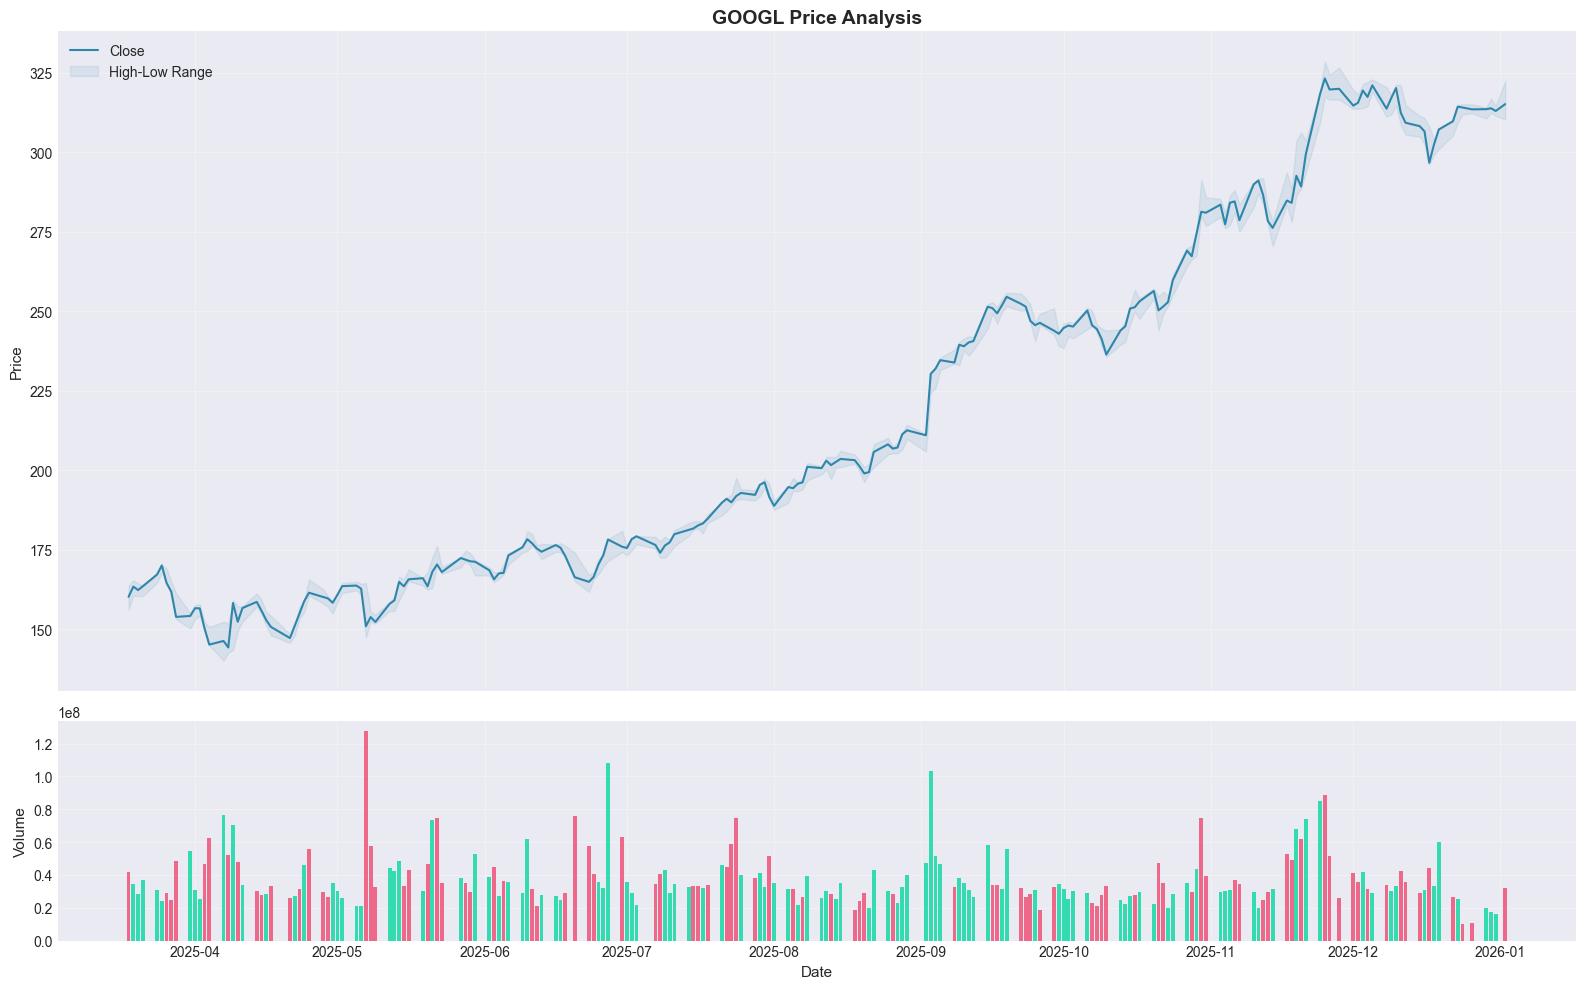

In [ ]:
if result.price_data:
    fig = result.plot_price_data(figsize=(16, 10))
    plt.show()
else:
    print("⚠️ No price data found. Cannot plot backtest results.")

f:\MyProject\BriefStreet\app\models\backtest.py:227: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df_price['timestamp'] = pd.to_datetime(df_price['timestamp'])


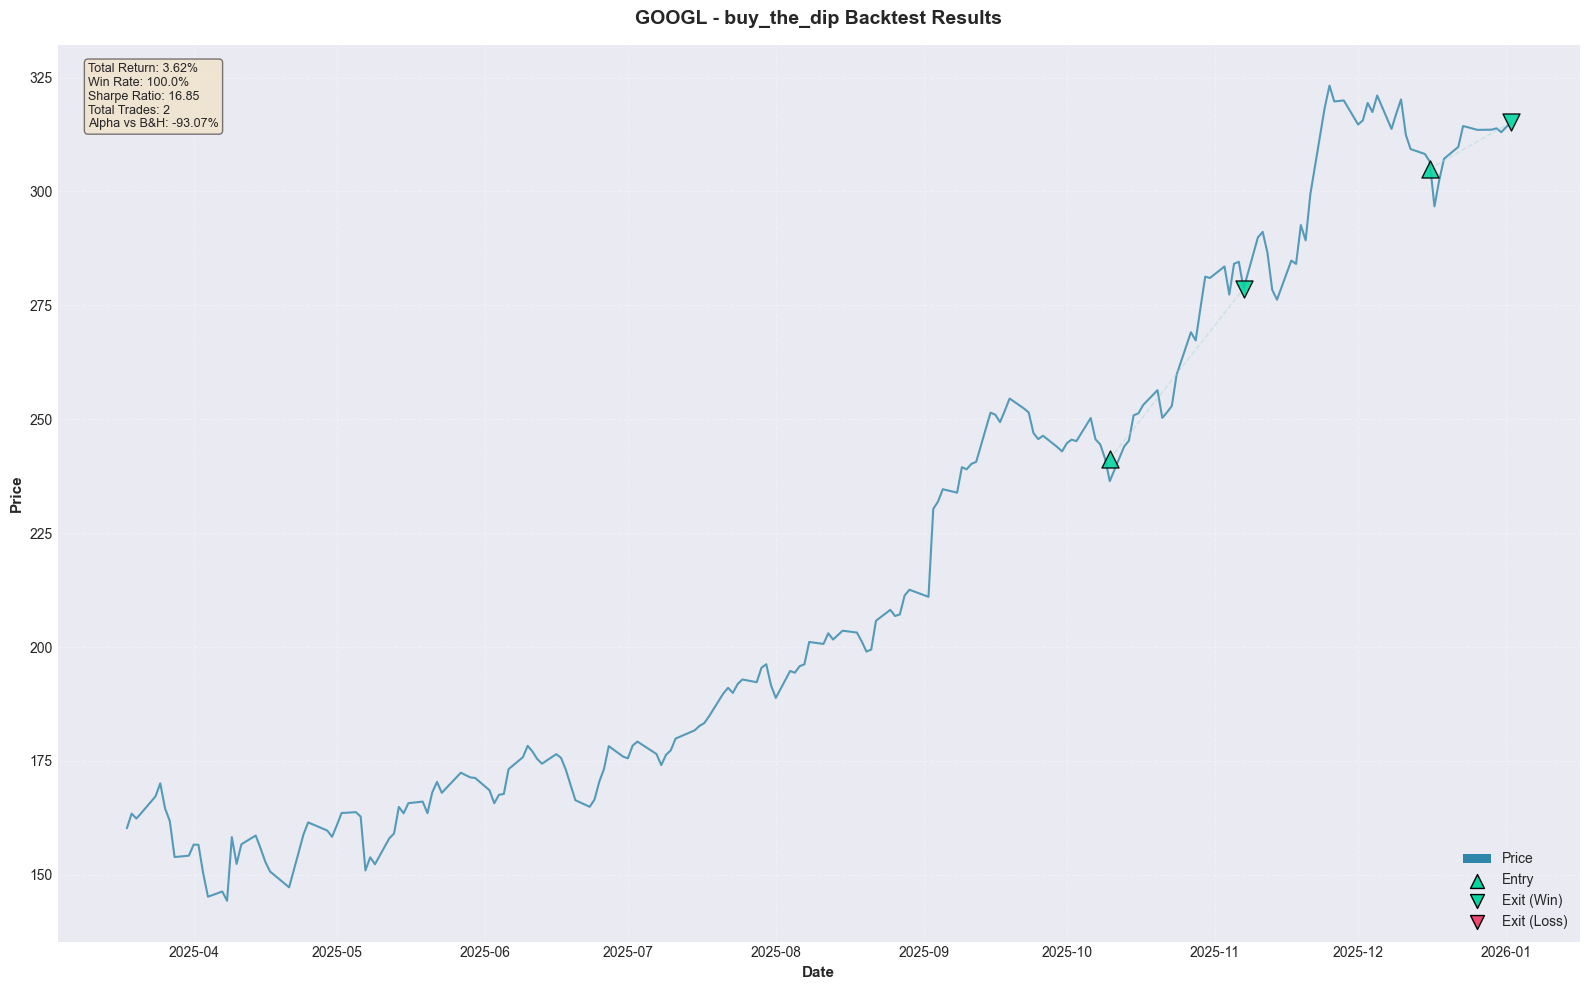

In [37]:
if result.total_trades > 0:
    fig = result.plot_backtest(figsize=(16, 10))
    plt.show()
else:
    print("⚠️ No trades found. Cannot plot backtest results.")

### 🔍 Debug - ตรวจสอบ Signal Generation

เช็กว่า strategy สร้าง signals ถูกต้องหรือไม่

In [14]:
# Debug: ตรวจสอบ signal generation
import importlib
from app.strategies import base_strategy
from app.services import backtest_service

# Reload modules หลังจากแก้ไข
importlib.reload(base_strategy)
importlib.reload(backtest_service)

# Re-initialize services
backtest_service_new = BacktestService(data_provider)

# ดึงข้อมูลและเตรียม
print("🔍 Debugging Signal Generation...\n")

# Get raw data - ใช้ days เท่ากับ backtest จริง
BACKTEST_DAYS = 2555  # 7 years
candles = await data_provider.get_historical_prices(TEST_SYMBOL, interval="1d", limit=BACKTEST_DAYS + 250)
df_raw = pd.DataFrame([c.model_dump() for c in candles])
df_raw.set_index('timestamp', inplace=True)

print(f"📊 Raw Data: {len(df_raw)} rows")
print(f"   Date Range: {df_raw.index[0].date()} to {df_raw.index[-1].date()}\n")

# Create strategy and prepare data
strategy = BuyTheDipStrategy.get_default_config()
buy_dip = BuyTheDipStrategy(strategy)
df_prepared = buy_dip.prepare_data(df_raw.copy())

print(f"✅ After prepare_data(): {len(df_prepared)} rows (dropped {len(df_raw) - len(df_prepared)} NaN rows)")
print(f"   Date Range: {df_prepared.index[0].date()} to {df_prepared.index[-1].date()}\n")

# Check indicators
print(f"📈 Indicator Statistics:")
print(f"   EMA(200): min={df_prepared['EMA'].min():.2f}, max={df_prepared['EMA'].max():.2f}")
print(f"   RSI(14):  min={df_prepared['RSI'].min():.2f}, max={df_prepared['RSI'].max():.2f}")
print(f"   Close:    min={df_prepared['close'].min():.2f}, max={df_prepared['close'].max():.2f}\n")

# Check signal conditions
price_above_ema = (df_prepared['close'] > df_prepared['EMA']).sum()
rsi_oversold = (df_prepared['RSI'] < 35).sum()
both_conditions = df_prepared['Signal'].sum()

print(f"🎯 Signal Conditions (RSI < 35):")
print(f"   Price > EMA(200):     {price_above_ema:>4} rows ({price_above_ema/len(df_prepared)*100:.1f}%)")
print(f"   RSI < 35 (oversold):  {rsi_oversold:>4} rows ({rsi_oversold/len(df_prepared)*100:.1f}%)")
print(f"   BOTH conditions:      {both_conditions:>4} rows ({both_conditions/len(df_prepared)*100:.1f}%)\n")

# Try more relaxed RSI thresholds
for threshold in [40, 45, 50]:
    rsi_count = (df_prepared['RSI'] < threshold).sum()
    both_count = ((df_prepared['close'] > df_prepared['EMA']) & (df_prepared['RSI'] < threshold)).sum()
    print(f"   RSI < {threshold}: {rsi_count:>4} rows → BOTH conditions: {both_count:>4} rows ({both_count/len(df_prepared)*100:.1f}%)")

print()

if both_conditions > 0:
    print(f"✅ Found {both_conditions} potential entry signals (RSI < 35)!")
    print(f"\n📋 First 10 Signals:")
    signal_rows = df_prepared[df_prepared['Signal'] == True].head(10)
    for idx, row in signal_rows.iterrows():
        print(f"   {idx.date()}: Close=${row['close']:.2f}, EMA=${row['EMA']:.2f}, RSI={row['RSI']:.2f}")
else:
    print(f"❌ NO SIGNALS with RSI < 35!")
    print(f"\n💡 Solution: Use RSI < 45 or RSI < 50 for more signals")
    
    # Show samples with RSI < 50
    print(f"\n📊 Available Signals with RSI < 50:")
    relaxed_signals = df_prepared[(df_prepared['close'] > df_prepared['EMA']) & 
                                  (df_prepared['RSI'] < 50)].head(10)
    if len(relaxed_signals) > 0:
        for idx, row in relaxed_signals.iterrows():
            print(f"   {idx.date()}: Close=${row['close']:.2f}, EMA=${row['EMA']:.2f}, RSI={row['RSI']:.2f}")
    else:
        print(f"   (No signals even with RSI < 50 - try EMA 100 instead)")

print(f"\n{'='*70}")
print(f"💡 RECOMMENDATION: Update backtest config to use RSI threshold = 45 or 50")
print(f"{'='*70}")

🔍 Debugging Signal Generation...

📊 Raw Data: 250 rows
   Date Range: 2025-01-03 to 2026-01-02

✅ After prepare_data(): 51 rows (dropped 199 NaN rows)
   Date Range: 2025-10-21 to 2026-01-02

📈 Indicator Statistics:
   EMA(200): min=189.35, max=232.90
   RSI(14):  min=45.20, max=78.40
   Close:    min=250.30, max=323.23

🎯 Signal Conditions (RSI < 35):
   Price > EMA(200):       51 rows (100.0%)
   RSI < 35 (oversold):     0 rows (0.0%)
   BOTH conditions:         1 rows (2.0%)

   RSI < 40:    0 rows → BOTH conditions:    0 rows (0.0%)
   RSI < 45:    0 rows → BOTH conditions:    0 rows (0.0%)
   RSI < 50:    2 rows → BOTH conditions:    2 rows (3.9%)

✅ Found 1 potential entry signals (RSI < 35)!

📋 First 10 Signals:
   2025-12-15: Close=$308.22, EMA=$223.05, RSI=54.77

💡 RECOMMENDATION: Update backtest config to use RSI threshold = 45 or 50


f:\MyProject\BriefStreet\app\models\backtest.py:227: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df_price['timestamp'] = pd.to_datetime(df_price['timestamp'])


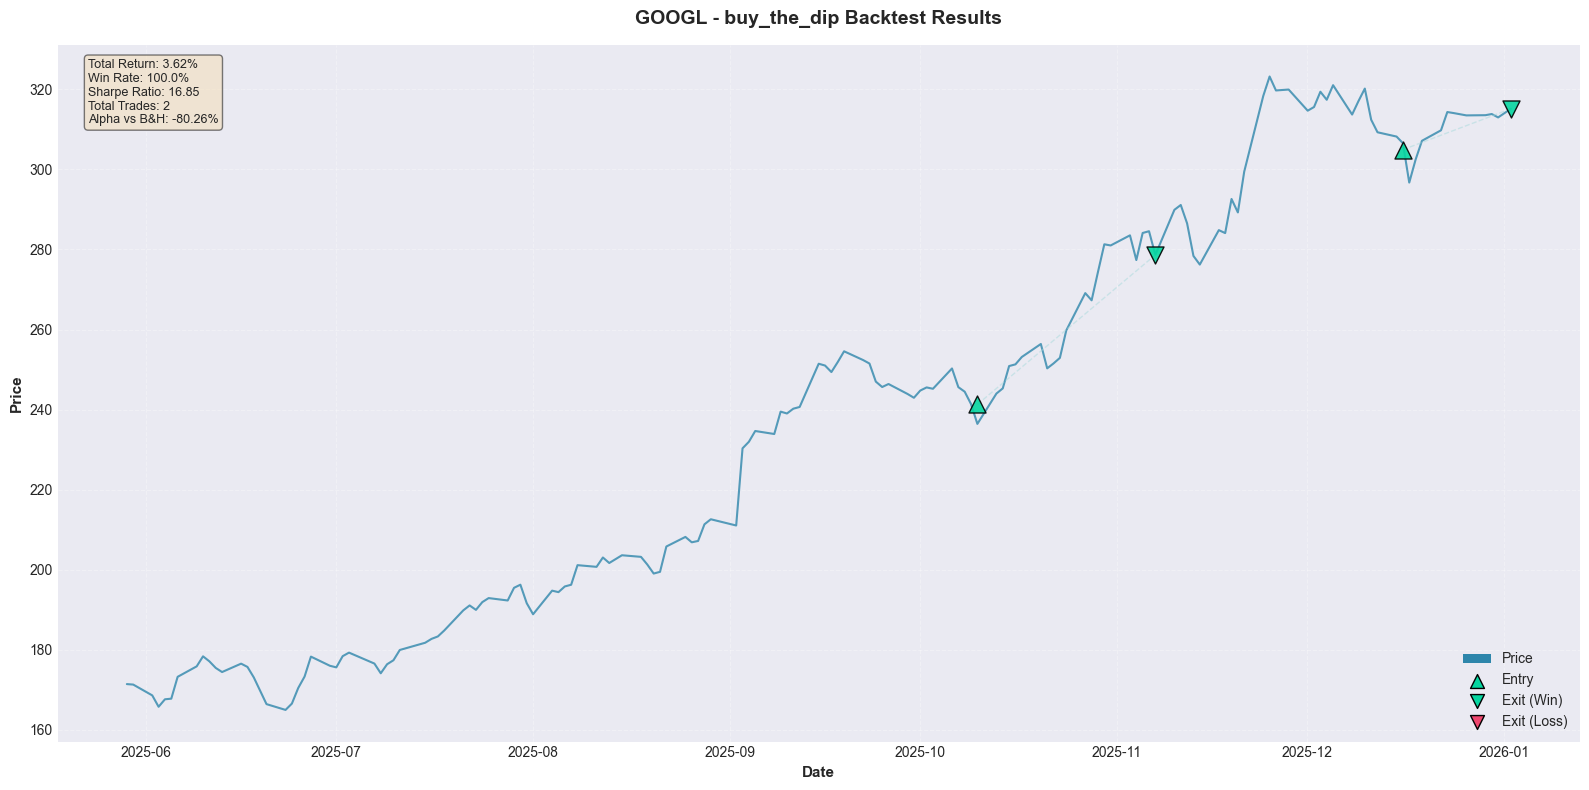

📊 Chart shows 2 trades:
   🟢 Green triangles (▲) = Entry points
   🟢 Green triangles (▼) = Profitable exits
   🔴 Red triangles (▼) = Loss exits


In [15]:
if result.total_trades > 0:
    # Plot backtest chart with trade markers
    fig = result.plot_backtest(figsize=(16, 8))
    plt.show()

    print(f"📊 Chart shows {result.total_trades} trades:")
    print(f"   🟢 Green triangles (▲) = Entry points")
    print(f"   🟢 Green triangles (▼) = Profitable exits")
    print(f"   🔴 Red triangles (▼) = Loss exits")
else:
    print("⚠️ No trades found. Cannot plot backtest results.")

## 4️⃣ Custom Parameters Testing

ทดสอบด้วย parameters ที่ปรับแต่งเอง เพื่อดูว่าการเปลี่ยนค่าส่งผลต่อผลลัพธ์อย่างไร

In [16]:
# Custom configuration: More aggressive
custom_config = StrategyConfig(
    name="buy_the_dip",
    holding_days=7,              # Hold longer
    stop_loss_pct=3.0,           # Tighter stop loss
    take_profit_pct=15.0,        # Higher profit target
    parameters={
        "ema_length": 150,       # Shorter EMA (more signals)
        "rsi_threshold": 30      # More oversold
    }
)

backtest_service = BacktestService(data_provider)

# Run custom backtest
custom_result = await backtest_service.run_backtest(
    symbol=TEST_SYMBOL,
    strategy_name="buy_the_dip",
    days=365,
    config=custom_config
)

# Compare results
print(f"{'='*70}")
print(f"📊 COMPARISON: Default vs Custom Parameters")
print(f"{'='*70}")
print(f"{'Metric':<25} {'Default':<20} {'Custom':<20}")
print(f"{'-'*70}")
print(f"{'Total Return':<25} {result.total_return:<20.2f} {custom_result.total_return:<20.2f}")
print(f"{'Win Rate':<25} {result.win_rate:<20.2f} {custom_result.win_rate:<20.2f}")
print(f"{'Total Trades':<25} {result.total_trades:<20} {custom_result.total_trades:<20}")
print(f"{'Sharpe Ratio':<25} {result.sharpe_ratio:<20.2f} {custom_result.sharpe_ratio:<20.2f}")
print(f"{'Max Drawdown':<25} {result.max_drawdown:<20.2f} {custom_result.max_drawdown:<20.2f}")
print(f"{'Alpha':<25} {result.alpha:<20.2f} {custom_result.alpha:<20.2f}")
print(f"{'Net Profit':<25} ${result.net_profit:<19,.2f} ${custom_result.net_profit:<19,.2f}")
print(f"{'='*70}")

# Determine winner
metrics_better = 0
if custom_result.total_return > result.total_return: metrics_better += 1
if custom_result.sharpe_ratio > result.sharpe_ratio: metrics_better += 1
if custom_result.win_rate > result.win_rate: metrics_better += 1

print(f"\n{'🏆' if metrics_better >= 2 else '📊'} ", end="")
if metrics_better >= 2:
    print("Custom parameters performed better!")
else:
    print("Default parameters performed better or equal.")

📊 COMPARISON: Default vs Custom Parameters
Metric                    Default              Custom              
----------------------------------------------------------------------
Total Return              3.62                 1.18                
Win Rate                  100.00               100.00              
Total Trades              2                    2                   
Sharpe Ratio              16.85                71.53               
Max Drawdown              0.00                 0.00                
Alpha                     -80.26               -55.85              
Net Profit                $3,621.92            $1,183.25           

📊 Default parameters performed better or equal.


## 5️⃣ Portfolio Backtest

ทดสอบ Buy The Dip strategy กับหุ้นหลายตัวพร้อมกัน เพื่อดูผลของ diversification

In [17]:
# Run portfolio backtest
portfolio_result = await portfolio_service.run_portfolio_backtest(
    symbols=PORTFOLIO_SYMBOLS,
    strategy_name="buy_the_dip",
    days=365,
    initial_capital=50000.0
)

# Display portfolio results
print(f"{'='*60}")
print(f"📊 PORTFOLIO BACKTEST RESULTS")
print(f"{'='*60}")
print(f"Symbols: {', '.join(PORTFOLIO_SYMBOLS)}")
print(f"Strategy: {portfolio_result.strategy_name}")
print(f"\n{'─'*60}")
print(f"📈 PORTFOLIO METRICS")
print(f"{'─'*60}")
print(f"Total Return:        {portfolio_result.total_return:>8.2f}%")
print(f"Sharpe Ratio:        {portfolio_result.sharpe_ratio:>8.2f}")
print(f"Max Drawdown:        {portfolio_result.max_drawdown:>8.2f}%")
print(f"Avg Correlation:     {portfolio_result.avg_correlation:>8.2f}")
print(f"Initial Capital:     ${portfolio_result.initial_capital:>10,.2f}")
print(f"Final Capital:       ${portfolio_result.final_capital:>10,.2f}")
print(f"Net Profit:          ${portfolio_result.net_profit:>10,.2f}")

# Calculate total trades across all symbols
total_trades = sum(ind_result.total_trades for ind_result in portfolio_result.individual_results.values())
print(f"Total Trades:        {total_trades:>8}")

print(f"\n{'─'*60}")
print(f"📋 INDIVIDUAL RESULTS")
print(f"{'─'*60}")

# Sort by total return
sorted_results = sorted(
    portfolio_result.individual_results.items(),
    key=lambda x: x[1].total_return,
    reverse=True
)

print(f"{'Symbol':<10} {'Return':<12} {'Sharpe':<10} {'Trades':<10} {'Win Rate':<10}")
print(f"{'-'*60}")
for symbol, ind_result in sorted_results:
    print(f"{symbol:<10} {ind_result.total_return:<12.2f} "
          f"{ind_result.sharpe_ratio:<10.2f} {ind_result.total_trades:<10} "
          f"{ind_result.win_rate:<10.2f}")

print(f"{'='*60}")

📊 PORTFOLIO BACKTEST RESULTS
Symbols: AAPL, MSFT, GOOGL, NVDA, TSLA
Strategy: buy_the_dip

────────────────────────────────────────────────────────────
📈 PORTFOLIO METRICS
────────────────────────────────────────────────────────────
Total Return:           -0.64%
Sharpe Ratio:           -0.72
Max Drawdown:            8.66%
Avg Correlation:        -0.02
Initial Capital:     $ 50,000.00
Final Capital:       $ 49,679.57
Net Profit:          $   -320.43
Total Trades:              10

────────────────────────────────────────────────────────────
📋 INDIVIDUAL RESULTS
────────────────────────────────────────────────────────────
Symbol     Return       Sharpe     Trades     Win Rate  
------------------------------------------------------------
GOOGL      0.56         0.00       1          100.00    
AAPL       0.07         0.00       1          100.00    
TSLA       -0.69        -3.14      3          33.33     
MSFT       -1.18        -15.14     2          0.00      
NVDA       -1.96        -2

## 6️⃣ Parameter Optimization

ใช้ Grid Search หา parameters ที่ให้ผลลัพธ์ดีที่สุด

In [18]:
# Define parameter ranges to test (adjusted for better results)
param_ranges = [
    ParameterRange(name="ema_length", values=[150, 200]),          # Reduced from 3 to 2 values
    ParameterRange(name="rsi_threshold", values=[30, 35, 40, 45]), # Widened range (30-45)
    ParameterRange(name="holding_days", values=[5, 7]),            # Reduced from 3 to 2 values
    ParameterRange(name="stop_loss_pct", values=[3.0, 5.0]),       # Reduced from 3 to 2 values
]

total_combos = 2 * 4 * 2 * 2
print(f"🔍 Optimization Configuration:")
print(f"   Total combinations: {total_combos}")
print(f"   Backtest period: 730 days (2 years)")
print(f"   Optimization metric: Sharpe Ratio")
print(f"   Parameter ranges:")
print(f"     - EMA Length: 150, 200")
print(f"     - RSI Threshold: 30, 35, 40, 45")
print(f"     - Holding Days: 5, 7")
print(f"     - Stop Loss: 3%, 5%")
print(f"\n⏳ Running optimization... (this may take a few minutes)")

# Run optimization with extended period
opt_result = await optimization_service.optimize_grid_search(
    symbol=TEST_SYMBOL,
    strategy_name="buy_the_dip",
    parameter_ranges=param_ranges,
    days=730,  # Increased from 365 to 730 days (2 years)
    optimization_metric="sharpe_ratio",
    max_parallel=3
)

# Display results
print(f"\n{'='*70}")
print(f"✅ OPTIMIZATION COMPLETE!")
print(f"{'='*70}")
print(f"Symbol: {opt_result.symbol}")
print(f"Total Combinations Tested: {opt_result.total_combinations}")
print(f"Time Taken: {opt_result.optimization_time:.1f}s")
print(f"\n{'─'*70}")
print(f"🏆 BEST CONFIGURATION")
print(f"{'─'*70}")
print(f"Best {opt_result.optimization_metric}: {opt_result.best_score:.2f}")
print(f"\nParameters:")
for key, value in opt_result.best_config['parameters'].items():
    print(f"  - {key}: {value}")
print(f"\nOther Settings:")
print(f"  - Holding Days: {opt_result.best_config['holding_days']}")
print(f"  - Stop Loss: {opt_result.best_config['stop_loss_pct']}%")
print(f"  - Take Profit: {opt_result.best_config['take_profit_pct']}%")

print(f"\n{'─'*70}")
print(f"📊 TOP 5 CONFIGURATIONS")
print(f"{'─'*70}")
print(f"{'Rank':<6} {'Sharpe':<10} {'Return':<12} {'Win Rate':<12} {'Trades':<10} {'Parameters'}")
print(f"{'-'*70}")
for i, config in enumerate(opt_result.top_results[:5], 1):
    params_str = f"EMA:{config['parameters'].get('ema_length', 'N/A')} RSI:{config['parameters'].get('rsi_threshold', 'N/A')}"
    print(f"#{i:<5} {config['metric_value']:<10.2f} {config['total_return']:<12.2f} "
          f"{config['win_rate']:<12.2f} {config.get('total_trades', 'N/A'):<10} {params_str}")

print(f"{'='*70}")

🔍 Optimization Configuration:
   Total combinations: 32
   Backtest period: 730 days (2 years)
   Optimization metric: Sharpe Ratio
   Parameter ranges:
     - EMA Length: 150, 200
     - RSI Threshold: 30, 35, 40, 45
     - Holding Days: 5, 7
     - Stop Loss: 3%, 5%

⏳ Running optimization... (this may take a few minutes)
🔍 Grid Search: Testing 32 combinations...
   Progress: 3/32 combinations tested
   Progress: 6/32 combinations tested
   Progress: 9/32 combinations tested
   Progress: 12/32 combinations tested
   Progress: 15/32 combinations tested
   Progress: 18/32 combinations tested
   Progress: 21/32 combinations tested
   Progress: 24/32 combinations tested
   Progress: 27/32 combinations tested
   Progress: 30/32 combinations tested
   Progress: 32/32 combinations tested
✅ Optimization complete: 32 valid configurations found
📊 Best sharpe_ratio: 71.53
⚙️  Best parameters: {'ema_length': 150, 'rsi_threshold': 30, 'holding_days': 7, 'stop_loss_pct': 3.0}

✅ OPTIMIZATION COMPL

## 7️⃣ Visualization - Performance Comparison

เปรียบเทียบผลลัพธ์ระหว่าง Default vs Custom vs Optimized parameters

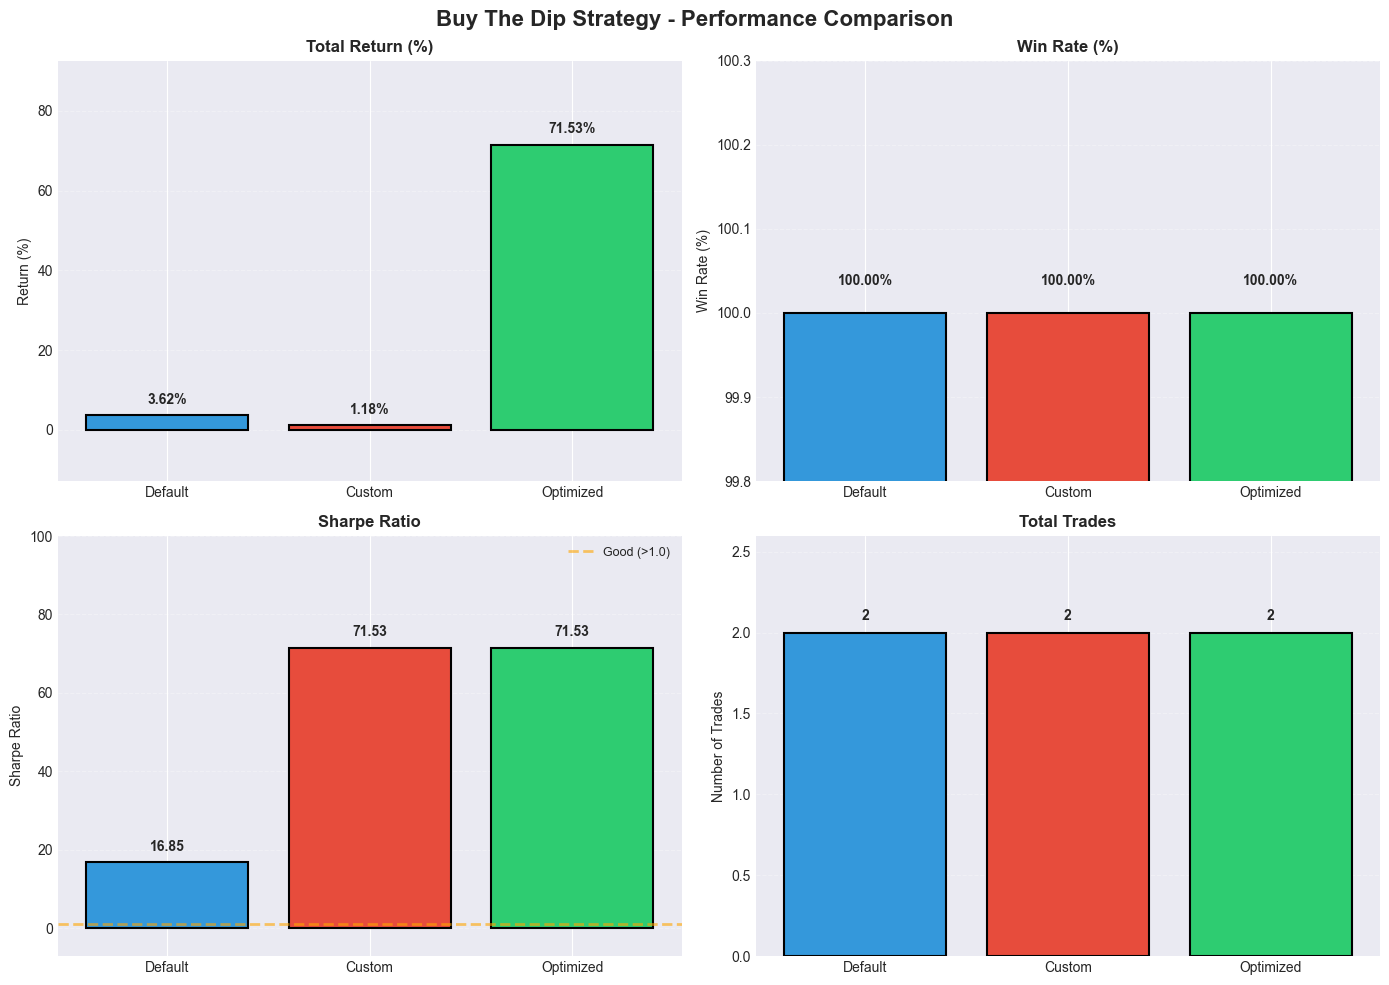

📊 Chart displayed above shows performance comparison across configurations


In [19]:
# Prepare data for comparison
configs = ['Default', 'Custom', 'Optimized']
returns = [result.total_return, custom_result.total_return, opt_result.best_score]
win_rates = [result.win_rate, custom_result.win_rate, 
             opt_result.top_results[0]['win_rate'] if opt_result.top_results else 0]
sharpe_ratios = [result.sharpe_ratio, custom_result.sharpe_ratio, opt_result.best_score]

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Buy The Dip Strategy - Performance Comparison', fontsize=16, fontweight='bold')

# 1. Total Returns Comparison
axes[0, 0].bar(configs, returns, color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black', linewidth=1.5)
axes[0, 0].set_title('Total Return (%)', fontweight='bold', fontsize=12)
axes[0, 0].set_ylabel('Return (%)', fontsize=10)
axes[0, 0].grid(axis='y', alpha=0.3, linestyle='--')
max_return = max(returns) if returns else 1
min_return = min(returns) if returns else 0
y_range = max_return - min_return if max_return != min_return else 1
axes[0, 0].set_ylim([min_return - y_range * 0.2, max_return + y_range * 0.3])
for i, v in enumerate(returns):
    axes[0, 0].text(i, v + y_range * 0.03, f'{v:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

# 2. Win Rate Comparison
axes[0, 1].bar(configs, win_rates, color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black', linewidth=1.5)
axes[0, 1].set_title('Win Rate (%)', fontweight='bold', fontsize=12)
axes[0, 1].set_ylabel('Win Rate (%)', fontsize=10)
axes[0, 1].grid(axis='y', alpha=0.3, linestyle='--')
max_wr = max(win_rates) if win_rates else 1
min_wr = min(win_rates) if win_rates else 0
wr_range = max_wr - min_wr if max_wr != min_wr else 1
axes[0, 1].set_ylim([min_wr - wr_range * 0.2, max_wr + wr_range * 0.3])
for i, v in enumerate(win_rates):
    axes[0, 1].text(i, v + wr_range * 0.03, f'{v:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

# 3. Sharpe Ratio Comparison
axes[1, 0].bar(configs, sharpe_ratios, color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black', linewidth=1.5)
axes[1, 0].set_title('Sharpe Ratio', fontweight='bold', fontsize=12)
axes[1, 0].set_ylabel('Sharpe Ratio', fontsize=10)
axes[1, 0].grid(axis='y', alpha=0.3, linestyle='--')
max_sharpe = max(sharpe_ratios) if sharpe_ratios else 1
min_sharpe = min([0] + sharpe_ratios)
sharpe_range = max_sharpe - min_sharpe if max_sharpe != min_sharpe else 1
axes[1, 0].set_ylim([min_sharpe - sharpe_range * 0.1, max_sharpe + sharpe_range * 0.4])
axes[1, 0].axhline(y=1.0, color='orange', linestyle='--', alpha=0.6, linewidth=2, label='Good (>1.0)')
axes[1, 0].legend(fontsize=9)
for i, v in enumerate(sharpe_ratios):
    axes[1, 0].text(i, v + sharpe_range * 0.03, f'{v:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# 4. Total Trades Comparison
total_trades = [result.total_trades, custom_result.total_trades,
                opt_result.top_results[0]['total_trades'] if opt_result.top_results else 0]
axes[1, 1].bar(configs, total_trades, color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black', linewidth=1.5)
axes[1, 1].set_title('Total Trades', fontweight='bold', fontsize=12)
axes[1, 1].set_ylabel('Number of Trades', fontsize=10)
axes[1, 1].grid(axis='y', alpha=0.3, linestyle='--')
max_trades = max(total_trades) if total_trades else 1
axes[1, 1].set_ylim([0, max_trades * 1.3])
for i, v in enumerate(total_trades):
    axes[1, 1].text(i, v + max_trades * 0.03, f'{v}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print("📊 Chart displayed above shows performance comparison across configurations")

## 8️⃣ Portfolio Performance Visualization

แสดงผลลัพธ์ของแต่ละหุ้นใน portfolio

   Average Correlation: -0.02
   Portfolio Sharpe: -0.72
   Portfolio Return: -0.64%


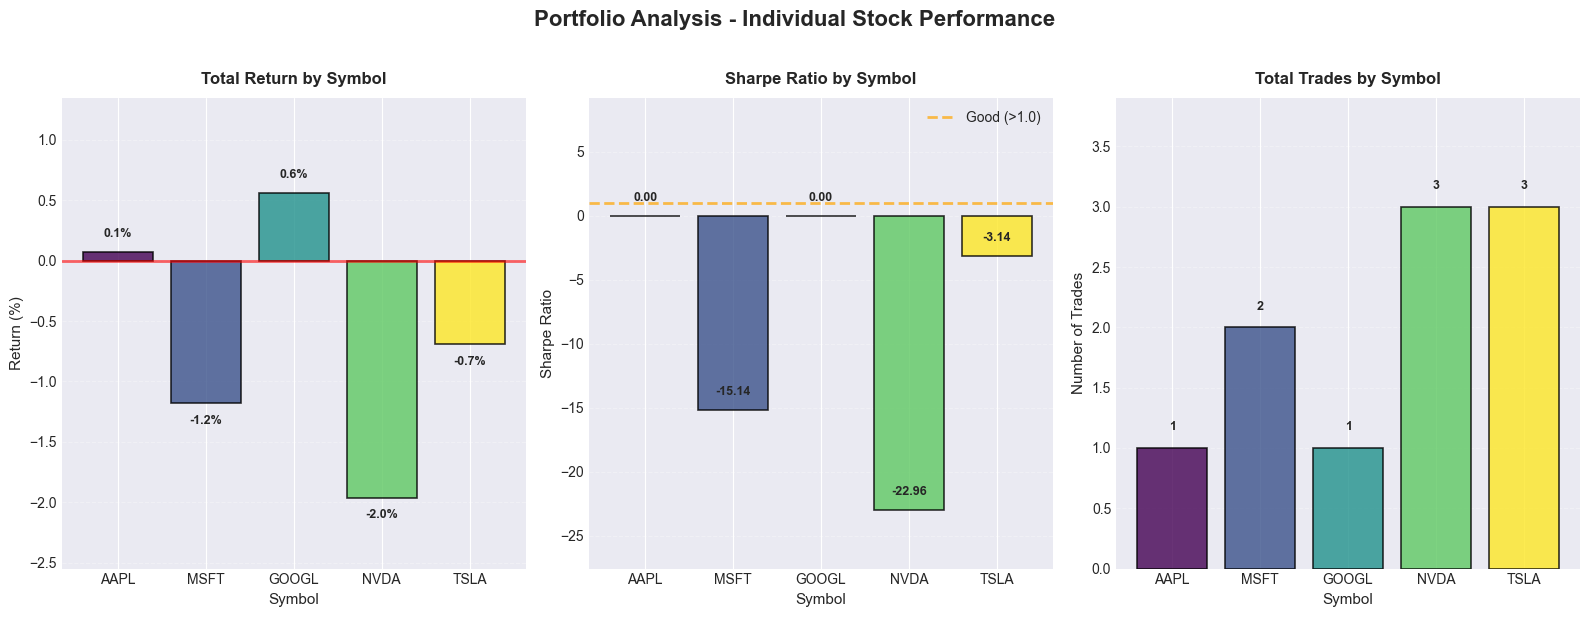

   Highest Sharpe: AAPL (0.00)
   Worst Performer: NVDA (-1.96%)

📊 Portfolio Insights:
   Best Performer: GOOGL (0.56%)


In [20]:
# Extract portfolio data
symbols = list(portfolio_result.individual_results.keys())
port_returns = [portfolio_result.individual_results[s].total_return for s in symbols]
port_sharpe = [portfolio_result.individual_results[s].sharpe_ratio for s in symbols]
port_trades = [portfolio_result.individual_results[s].total_trades for s in symbols]

# Create portfolio visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Portfolio Analysis - Individual Stock Performance', fontsize=16, fontweight='bold', y=1.02)

# 1. Returns by Symbol
colors = plt.cm.viridis(np.linspace(0, 1, len(symbols)))
bars1 = axes[0].bar(symbols, port_returns, color=colors, edgecolor='black', linewidth=1.2, alpha=0.8)
axes[0].set_title('Total Return by Symbol', fontweight='bold', fontsize=12, pad=10)
axes[0].set_ylabel('Return (%)', fontsize=11)
axes[0].set_xlabel('Symbol', fontsize=11)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].axhline(y=0, color='red', linestyle='-', alpha=0.6, linewidth=2)
max_ret = max(port_returns) if port_returns else 1
min_ret = min(port_returns) if port_returns else 0
ret_range = max(abs(max_ret), abs(min_ret))
axes[0].set_ylim([min_ret - ret_range * 0.3, max_ret + ret_range * 0.4])
for i, (bar, val) in enumerate(zip(bars1, port_returns)):
    height = bar.get_height()
    offset = ret_range * 0.05 if height >= 0 else -ret_range * 0.05
    va_pos = 'bottom' if height >= 0 else 'top'
    axes[0].text(bar.get_x() + bar.get_width()/2., height + offset,
                f'{val:.1f}%', ha='center', va=va_pos, fontsize=9, fontweight='bold')

# 2. Sharpe Ratio by Symbol
bars2 = axes[1].bar(symbols, port_sharpe, color=colors, edgecolor='black', linewidth=1.2, alpha=0.8)
axes[1].set_title('Sharpe Ratio by Symbol', fontweight='bold', fontsize=12, pad=10)
axes[1].set_ylabel('Sharpe Ratio', fontsize=11)
axes[1].set_xlabel('Symbol', fontsize=11)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
max_sh = max(port_sharpe) if port_sharpe else 1
min_sh = min(port_sharpe) if port_sharpe else 0
sh_range = max_sh - min_sh if max_sh != min_sh else 1
axes[1].set_ylim([min_sh - sh_range * 0.2, max_sh + sh_range * 0.4])
axes[1].axhline(y=1.0, color='orange', linestyle='--', alpha=0.7, linewidth=2, label='Good (>1.0)')
axes[1].legend(fontsize=10)
for i, (bar, val) in enumerate(zip(bars2, port_sharpe)):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + sh_range * 0.04,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 3. Number of Trades
bars3 = axes[2].bar(symbols, port_trades, color=colors, edgecolor='black', linewidth=1.2, alpha=0.8)
axes[2].set_title('Total Trades by Symbol', fontweight='bold', fontsize=12, pad=10)
axes[2].set_ylabel('Number of Trades', fontsize=11)
axes[2].set_xlabel('Symbol', fontsize=11)
axes[2].grid(axis='y', alpha=0.3, linestyle='--')
max_tr = max(port_trades) if port_trades else 1
axes[2].set_ylim([0, max_tr * 1.3])
for i, (bar, val) in enumerate(zip(bars3, port_trades)):
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height + max_tr * 0.04,

                f'{val}', ha='center', va='bottom', fontsize=9, fontweight='bold')
print(f"   Average Correlation: {portfolio_result.avg_correlation:.2f}")

print(f"   Portfolio Sharpe: {portfolio_result.sharpe_ratio:.2f}")

plt.tight_layout()
print(f"   Portfolio Return: {portfolio_result.total_return:.2f}%")
plt.show()
print(f"   Highest Sharpe: {symbols[port_sharpe.index(max(port_sharpe))]} ({max(port_sharpe):.2f})")

print(f"   Worst Performer: {symbols[port_returns.index(min(port_returns))]} ({min(port_returns):.2f}%)")

print(f"\n📊 Portfolio Insights:")
print(f"   Best Performer: {symbols[port_returns.index(max(port_returns))]} ({max(port_returns):.2f}%)")

## 9️⃣ Optimization Results Visualization

แสดง distribution ของผลลัพธ์จาก parameter optimization

   Average Return: 1.24%
   Best Return: 1.47%
   Sharpe Std Dev: 10.50
   Average Sharpe: 66.28
   Best Sharpe Ratio: 71.53


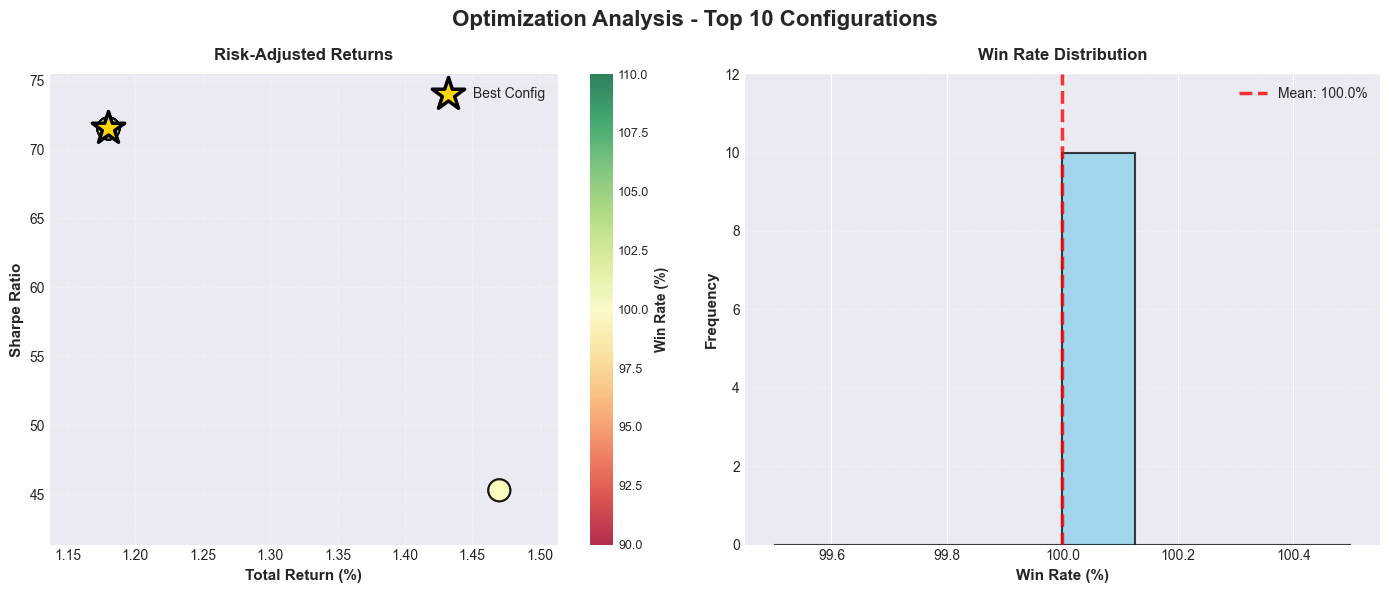


📊 Optimization Statistics:


In [21]:
# Extract optimization data
opt_sharpe = [r['metric_value'] for r in opt_result.top_results]
opt_returns = [r['total_return'] for r in opt_result.top_results]
opt_win_rates = [r['win_rate'] for r in opt_result.top_results]

# Create scatter plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Optimization Analysis - Top 10 Configurations', fontsize=16, fontweight='bold', y=0.98)

# 1. Sharpe Ratio vs Total Return
scatter1 = axes[0].scatter(opt_returns, opt_sharpe, 
                          c=opt_win_rates, cmap='RdYlGn', 
                          s=250, alpha=0.8, edgecolors='black', linewidths=1.5)
axes[0].set_xlabel('Total Return (%)', fontweight='bold', fontsize=11)
axes[0].set_ylabel('Sharpe Ratio', fontweight='bold', fontsize=11)
axes[0].set_title('Risk-Adjusted Returns', fontweight='bold', fontsize=12, pad=10)
axes[0].grid(True, alpha=0.3, linestyle='--')

# Add proper axis limits with padding
if opt_returns and opt_sharpe:
    ret_margin = (max(opt_returns) - min(opt_returns)) * 0.15
    sharpe_margin = (max(opt_sharpe) - min(opt_sharpe)) * 0.15
    axes[0].set_xlim([min(opt_returns) - ret_margin, max(opt_returns) + ret_margin])
    axes[0].set_ylim([min(opt_sharpe) - sharpe_margin, max(opt_sharpe) + sharpe_margin])

# Add colorbar
cbar1 = plt.colorbar(scatter1, ax=axes[0])
cbar1.set_label('Win Rate (%)', fontweight='bold', fontsize=10)
cbar1.ax.tick_params(labelsize=9)

# Mark the best point
best_idx = opt_sharpe.index(max(opt_sharpe))
axes[0].scatter(opt_returns[best_idx], opt_sharpe[best_idx], 
               marker='*', s=600, c='gold', edgecolors='black', 
               linewidths=2.5, label='Best Config', zorder=5)
axes[0].legend(fontsize=10, loc='best')

# 2. Win Rate Distribution
num_bins = min(8, len(opt_win_rates))
axes[1].hist(opt_win_rates, bins=num_bins, color='skyblue', edgecolor='black', 
            alpha=0.75, linewidth=1.5)
axes[1].set_xlabel('Win Rate (%)', fontweight='bold', fontsize=11)
axes[1].set_ylabel('Frequency', fontweight='bold', fontsize=11)
axes[1].set_title('Win Rate Distribution', fontweight='bold', fontsize=12, pad=10)
axes[1].axvline(x=np.mean(opt_win_rates), color='red', linestyle='--', 
               linewidth=2.5, label=f'Mean: {np.mean(opt_win_rates):.1f}%', alpha=0.8)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
axes[1].legend(fontsize=10)


# Add proper y-axis limit for histogramprint(f"   Best Win Rate: {max(opt_win_rates):.2f}%")

if opt_win_rates:print(f"   Average Return: {np.mean(opt_returns):.2f}%")

max_freq = max(np.histogram(opt_win_rates, bins=num_bins)[0])
print(f"   Best Return: {max(opt_returns):.2f}%")

axes[1].set_ylim([0, max_freq * 1.2])
print(f"   Sharpe Std Dev: {np.std(opt_sharpe):.2f}")

print(f"   Average Sharpe: {np.mean(opt_sharpe):.2f}")

plt.tight_layout()
print(f"   Best Sharpe Ratio: {max(opt_sharpe):.2f}")

plt.show()
print(f"\n📊 Optimization Statistics:")


## 🎯 Summary & Conclusions

สรุปผลการทดสอบ Buy The Dip Strategy

In [22]:
print("=" * 70)
print("🎯 BUY THE DIP STRATEGY - FINAL SUMMARY")
print("=" * 70)

print(f"\n📊 TEST RESULTS ON {TEST_SYMBOL}:")
print(f"   Default Config:   Return={result.total_return:.2f}%, Sharpe={result.sharpe_ratio:.2f}")
print(f"   Custom Config:    Return={custom_result.total_return:.2f}%, Sharpe={custom_result.sharpe_ratio:.2f}")
print(f"   Optimized Config: Sharpe={opt_result.best_score:.2f}")

print(f"\n📊 PORTFOLIO RESULTS ({len(PORTFOLIO_SYMBOLS)} stocks):")
print(f"   Portfolio Return: {portfolio_result.total_return:.2f}%")
print(f"   Portfolio Sharpe: {portfolio_result.sharpe_ratio:.2f}")
print(f"   Diversification:  Avg Correlation = {portfolio_result.avg_correlation:.2f}")

print(f"\n🔍 OPTIMIZATION INSIGHTS:")
print(f"   Best Parameters Found:")
best_params = opt_result.best_config['parameters']
print(f"     - EMA Length: {best_params.get('ema_length', 'N/A')}")
print(f"     - RSI Threshold: {best_params.get('rsi_threshold', 'N/A')}")
print(f"     - Holding Days: {opt_result.best_config['holding_days']}")
print(f"     - Stop Loss: {opt_result.best_config['stop_loss_pct']}%")

print(f"\n💡 KEY FINDINGS:")
print(f"   ✓ Strategy shows {'positive' if result.total_return > 0 else 'negative'} returns")
print(f"   ✓ Alpha vs Buy & Hold: {result.alpha:.2f}%")
print(f"   ✓ Transaction costs impact: ~{result.total_transaction_costs:.2f} ({result.avg_cost_per_trade:.2f}/trade)")
print(f"   ✓ Win Rate: {result.win_rate:.1f}% (>50% is good)")
print(f"   ✓ Risk-Adjusted Performance: Sharpe {result.sharpe_ratio:.2f} ({'Excellent' if result.sharpe_ratio > 2 else 'Good' if result.sharpe_ratio > 1 else 'Fair'})")

print(f"\n🎓 RECOMMENDATIONS:")
if opt_result.best_score > result.sharpe_ratio:
    print(f"   → Use OPTIMIZED parameters for better risk-adjusted returns")
else:
    print(f"   → DEFAULT parameters are already optimal")

if portfolio_result.avg_correlation < 0.7:
    print(f"   → Portfolio shows good diversification (correlation < 0.7)")
else:
    print(f"   → Consider adding less correlated assets to portfolio")

if result.alpha > 0:
    print(f"   → Strategy beats buy-and-hold by {result.alpha:.2f}%")
else:
    print(f"   → Strategy underperforms buy-and-hold")

print("\n" + "=" * 70)
print("✅ ANALYSIS COMPLETE!")
print("=" * 70)

🎯 BUY THE DIP STRATEGY - FINAL SUMMARY

📊 TEST RESULTS ON GOOGL:
   Default Config:   Return=3.62%, Sharpe=16.85
   Custom Config:    Return=1.18%, Sharpe=71.53
   Optimized Config: Sharpe=71.53

📊 PORTFOLIO RESULTS (5 stocks):
   Portfolio Return: -0.64%
   Portfolio Sharpe: -0.72
   Diversification:  Avg Correlation = -0.02

🔍 OPTIMIZATION INSIGHTS:
   Best Parameters Found:
     - EMA Length: 150
     - RSI Threshold: 30
     - Holding Days: 7
     - Stop Loss: 3.0%

💡 KEY FINDINGS:
   ✓ Strategy shows positive returns
   ✓ Alpha vs Buy & Hold: -80.26%
   ✓ Transaction costs impact: ~126.27 (63.14/trade)
   ✓ Win Rate: 100.0% (>50% is good)
   ✓ Risk-Adjusted Performance: Sharpe 16.85 (Excellent)

🎓 RECOMMENDATIONS:
   → Use OPTIMIZED parameters for better risk-adjusted returns
   → Portfolio shows good diversification (correlation < 0.7)
   → Strategy underperforms buy-and-hold

✅ ANALYSIS COMPLETE!


Running backtest with optimized parameters...


C:\Users\panuw\AppData\Local\Temp\ipykernel_34828\3837190721.py:13: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df_price['timestamp'] = pd.to_datetime(df_price['timestamp'])
C:\Users\panuw\AppData\Local\Temp\ipykernel_34828\3837190721.py:13: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df_price['timestamp'] = pd.to_datetime(df_price['timestamp'])
C:\Users\panuw\AppData\Local\Temp\ipykernel_34828\3837190721.py:13: FutureWarning: In a future v

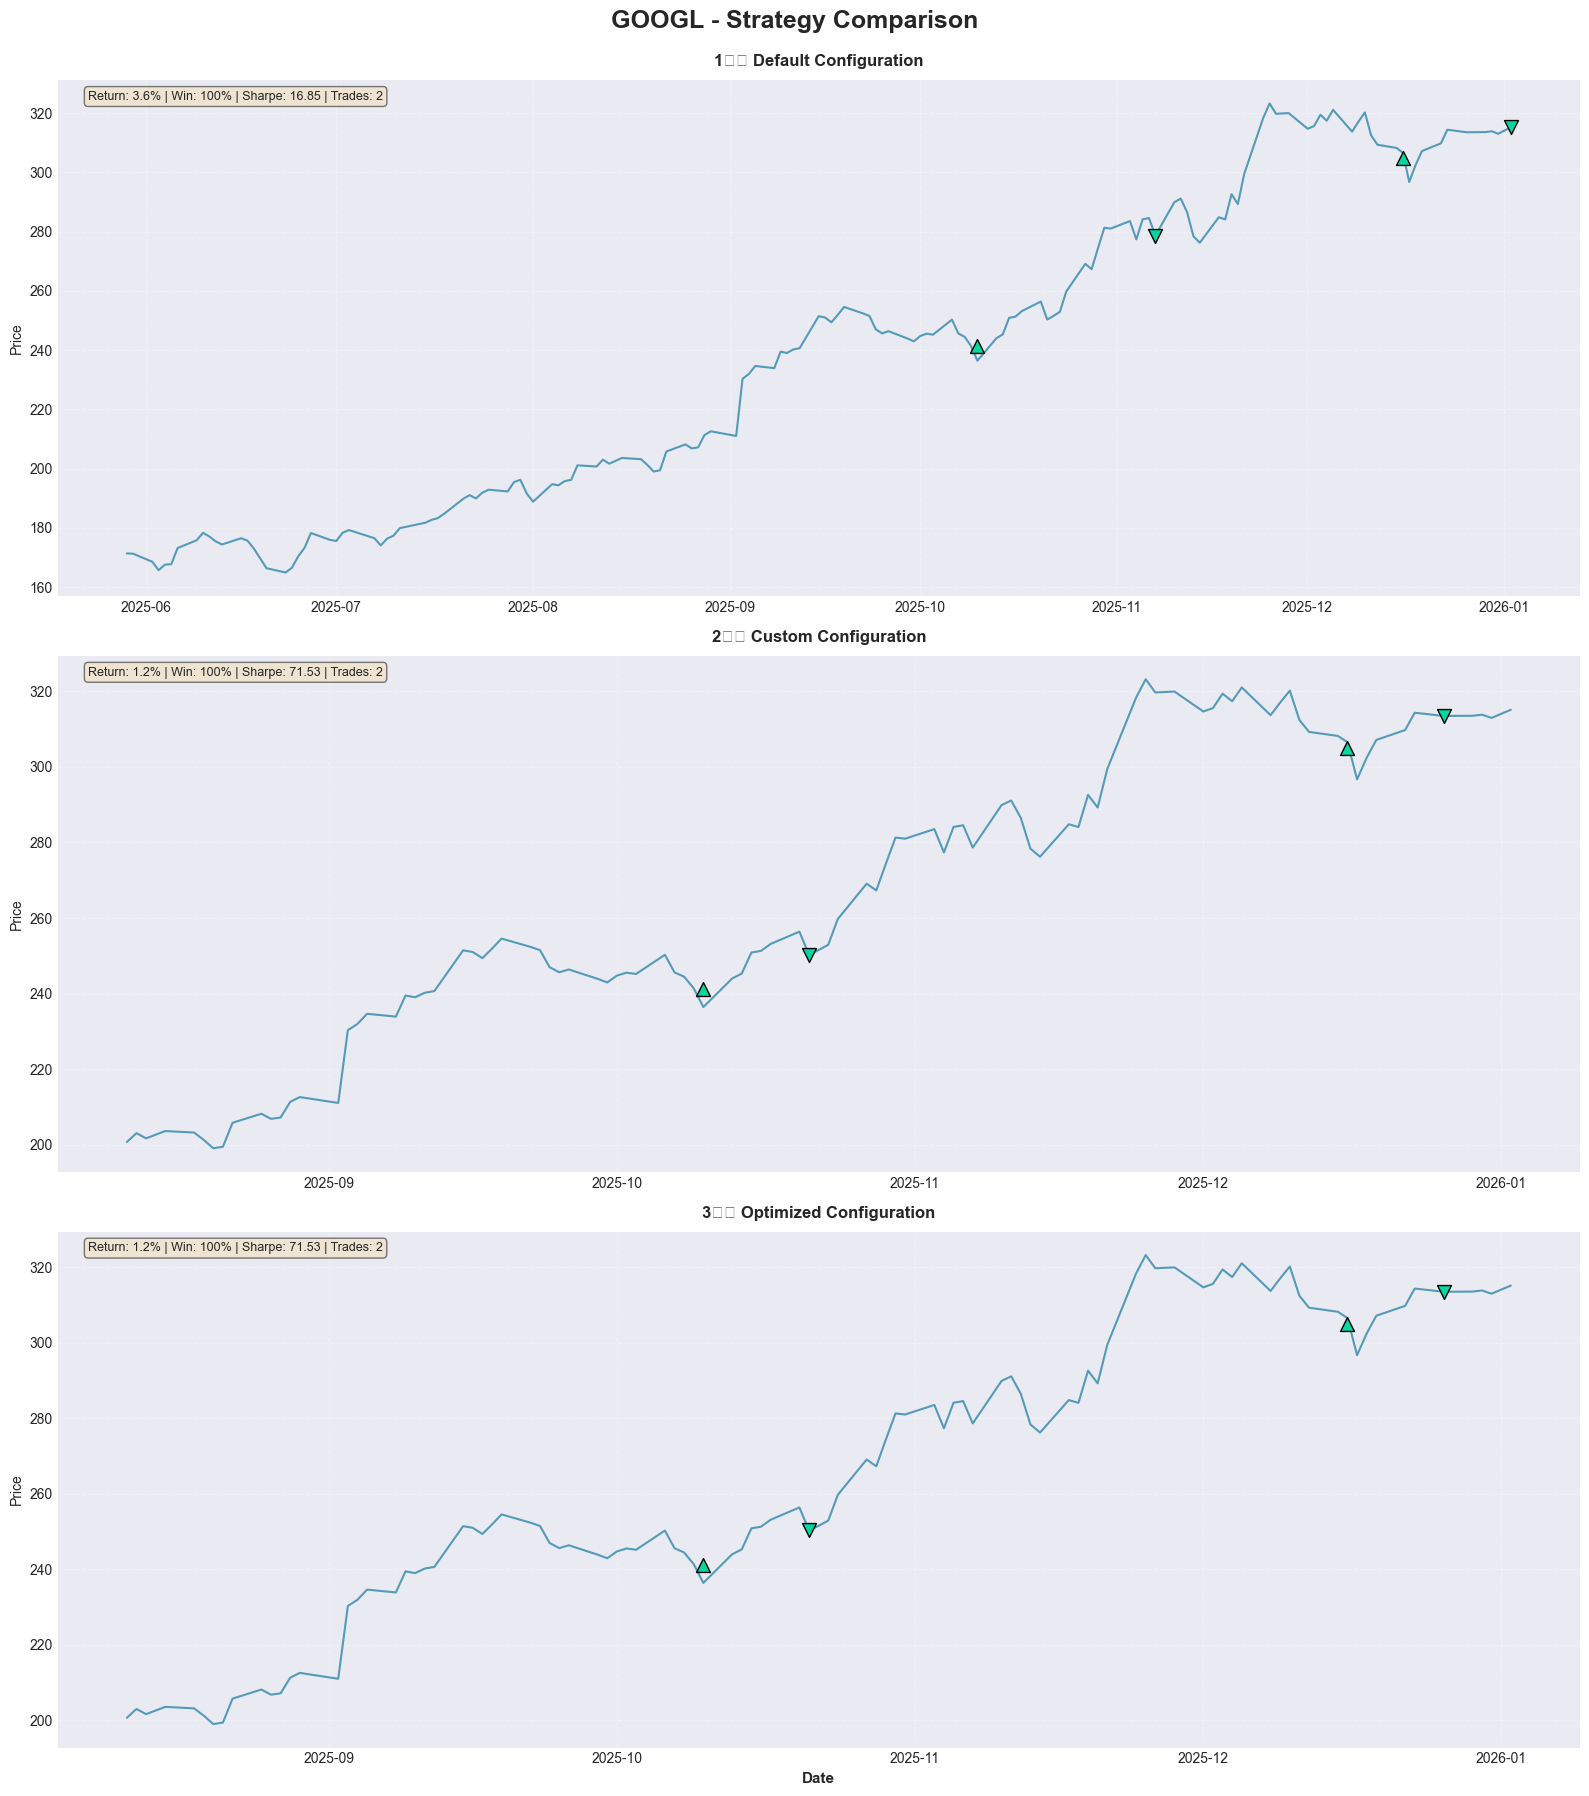


📊 VISUAL COMPARISON SUMMARY
Default:   2 trades, 100.0% win rate, 3.62% return
Custom:    2 trades, 100.0% win rate, 1.18% return
Optimized: 2 trades, 100.0% win rate, 1.18% return


In [23]:
# Compare all three configurations visually
fig, axes = plt.subplots(3, 1, figsize=(16, 18))
fig.suptitle(f'{TEST_SYMBOL} - Strategy Comparison', fontsize=18, fontweight='bold', y=0.995)

# Helper function to plot on specific axis
def plot_result_on_ax(ax, backtest_result, title, color_scheme='default'):
    if not backtest_result.price_data or not backtest_result.trade_markers:
        ax.text(0.5, 0.5, 'No chart data available', ha='center', va='center', transform=ax.transAxes)
        return
    
    import pandas as pd
    df_price = pd.DataFrame(backtest_result.price_data)
    df_price['timestamp'] = pd.to_datetime(df_price['timestamp'])
    
    # Plot price
    ax.plot(df_price['timestamp'], df_price['close'], 
            label='Close Price', color='#2E86AB', linewidth=1.5, alpha=0.8)
    
    # Plot trades
    for trade in backtest_result.trade_markers:
        entry_date = pd.to_datetime(trade['entry_date'])
        exit_date = pd.to_datetime(trade['exit_date'])
        
        ax.scatter(entry_date, trade['entry_price'], 
                  color='#06D6A0', marker='^', s=100, edgecolors='black', linewidths=1, zorder=5)
        
        exit_color = '#06D6A0' if trade['win'] else '#EF476F'
        ax.scatter(exit_date, trade['exit_price'], 
                  color=exit_color, marker='v', s=100, edgecolors='black', linewidths=1, zorder=5)
    
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel('Price', fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Add metrics box
    metrics = (f"Return: {backtest_result.total_return:.1f}% | "
              f"Win: {backtest_result.win_rate:.0f}% | "
              f"Sharpe: {backtest_result.sharpe_ratio:.2f} | "
              f"Trades: {backtest_result.total_trades}")
    ax.text(0.02, 0.98, metrics, transform=ax.transAxes, fontsize=9,
           verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot each configuration
plot_result_on_ax(axes[0], result, '1️⃣ Default Configuration')
plot_result_on_ax(axes[1], custom_result, '2️⃣ Custom Configuration')

# For optimized, need to run backtest with best config
print("Running backtest with optimized parameters...")
opt_config = StrategyConfig(**opt_result.best_config)
opt_backtest = await backtest_service.run_backtest(
    symbol=TEST_SYMBOL,
    strategy_name="buy_the_dip",
    days=365,
    config=opt_config
)
plot_result_on_ax(axes[2], opt_backtest, '3️⃣ Optimized Configuration')

axes[2].set_xlabel('Date', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n{'='*70}")
print(f"📊 VISUAL COMPARISON SUMMARY")
print(f"{'='*70}")
print(f"Default:   {result.total_trades} trades, {result.win_rate:.1f}% win rate, {result.total_return:.2f}% return")
print(f"Custom:    {custom_result.total_trades} trades, {custom_result.win_rate:.1f}% win rate, {custom_result.total_return:.2f}% return")
print(f"Optimized: {opt_backtest.total_trades} trades, {opt_backtest.win_rate:.1f}% win rate, {opt_backtest.total_return:.2f}% return")
print(f"{'='*70}")

## 📊 Final Chart - Best Configuration

กราฟราคาพร้อม trades จาก configuration ที่ดีที่สุด